In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from math import floor
from random import sample
import warnings
import time

sns.set(color_codes=True)

from lifelines.plotting import plot_lifetimes      # Lifeline package for the Survival Analysis
%pylab inline
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

warnings.filterwarnings('ignore')
%matplotlib inline

Populating the interactive namespace from numpy and matplotlib


In [6]:
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)
t = datetime.datetime.strptime("2020-W01-7", "%G-W%V-%u")
print(t)

2020-01-05 00:00:00
2020-01-05 00:00:00


In [9]:
%run ./CVGI_MR_00_functions.ipynb

Populating the interactive namespace from numpy and matplotlib


In [10]:
imports()

What is the source of the MOVEMENT data? (1=internet, 2=home Mac, 3=office Windows)2
What type of import is it? (1 = initial (only cases and movement), 2 = initial (full), 3 = data by week, 4 = merged datasets, 5 = only cases)4

../../02 data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185852 entries, 0 to 1185851
Data columns (total 8 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   date             1185852 non-null  datetime64[ns]
 1   GADM_GID_2       1185852 non-null  object        
 2   mun_name         1185852 non-null  object        
 3   movement_change  1185852 non-null  float64       
 4   stay_put         1185852 non-null  float64       
 5   epi_week         1185852 non-null  object        
 6   ibge_code        1185852 non-null  int64         
 7   pop_2020         1185852 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 72.4+ MB

++++++++++++

In [11]:
cases_by_epi_week_merged_clean = clean_cases_by_epi_week(cases_by_epi_week_merged)
cases_by_epi_week_merged_clean

,ibge_code,epi_week,acc_cases,acc_deaths,new_cases,new_deaths,pop_2019,epi_week_col,acc_cases_100k,acc_deaths_1mi,epi_week_date
0,1100015,2020.18,1,0,1,0,22945.0,2020.18,4.36,0.00,2020-05-10
1,1100015,2020.19,8,0,0,0,22945.0,2020.19,34.87,0.00,2020-05-17
2,1100015,2020.20,7,0,0,0,22945.0,2020.20,30.51,0.00,2020-05-24
3,1100015,2020.21,13,0,3,0,22945.0,2020.21,56.66,0.00,2020-05-31
4,1100015,2020.22,21,0,-1,0,22945.0,2020.22,91.52,0.00,2020-06-07
...,...,...,...,...,...,...,...,...,...,...,...
308030,5300108,2021.17,2316597,49512,6624,263,3015268.0,2021.17,76828.89,16420.43,2021-05-02
308031,5300108,2021.18,2358003,51165,5390,237,3015268.0,2021.18,78202.10,16968.64,2021-05-09
308032,5300108,2021.19,2396055,52654,5311,185,3015268.0,2021.19,79464.08,17462.46,2021-05-16
308033,5300108,2021.20,2433365,53799,5337,142,3015268.0,2021.20,80701.45,17842.20,2021-05-23


---

generating population data from the aggregate for one state in Brazil (let's pick RO, whichi is smaller)

In [4]:
%run ./CVGI_FB_functions.ipynb

code for one city, generates index from total deaths in that city

In [22]:
#slicing the cases dataset to get one city only (city selected randomly in this case)
cases_one_city = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == "1100023"][['epi_week','new_deaths']]
cases_one_city

,epi_week,new_deaths
57,2020.15,0
58,2020.16,0
59,2020.17,0
60,2020.18,0
61,2020.19,0
62,2020.20,0
63,2020.21,3
64,2020.22,1
65,2020.23,1
66,2020.24,4


In [23]:
events_one_city = pd.DataFrame({'event': pd.Series([], dtype='int'),'week':pd.Series([], dtype='int')}, index=range(cases_one_city.new_deaths.sum()))
start_time = time.time()

c = 0
for id_wk, val_wk in enumerate(cases_one_city.epi_week):
        #check if there are any cases, otherwise skip
        var_deaths = cases_one_city[(cases_one_city.epi_week == val_wk)].new_deaths.tolist()[0]
        #print(var_deaths,val_wk)
        if var_deaths > 0:
            for i in range(var_deaths):
              #print(c,cases_teste_pop.death_num.iloc[c], i)
              events_one_city['event'].iloc[c] = 1
              events_one_city['week'].iloc[c] = id_wk
              c = c + 1
t1 = "--- %s seconds ---" % (time.time() - start_time)
print(t1)

events_one_city

--- 0.23770999908447266 seconds ---


,event,week
0,1.0,6.0
1,1.0,6.0
2,1.0,6.0
3,1.0,7.0
4,1.0,8.0
...,...,...
422,1.0,58.0
423,1.0,58.0
424,1.0,59.0
425,1.0,59.0


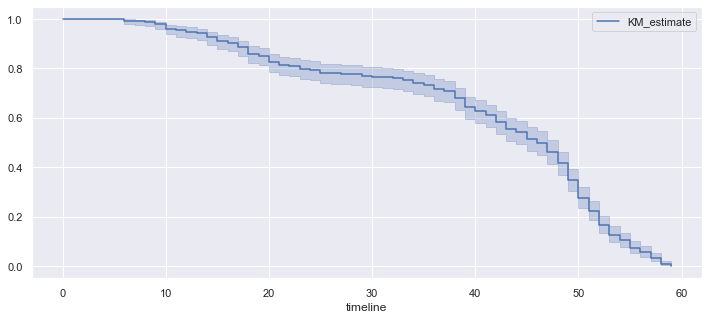

In [25]:
#generating the analysis to test the output
kmf2 = KaplanMeierFitter()

T = events_one_city['week']     ## time to event
E = events_one_city['event']      ## variable indicating the event

kmf2.fit(T,E)
figsize(12,5)
a1 = kmf2.plot()
plt.show()

---

implementing as a function to be iterated for more cities

In [161]:
def events_cities(cases):
    start_time = time.time()
    total_deaths = 0
    for id_wk, val_wk in enumerate(cases.epi_week):
        #check if there are any cases, otherwise skip
        var_deaths = cases[(cases.epi_week == val_wk)].new_deaths.tolist()[0]
        #check if the death number of a city is positive. we are ignoring the negative numbers.
        if var_deaths > 0: total_deaths = total_deaths + var_deaths
    events = pd.DataFrame({'event': pd.Series([], dtype='int'),'week':pd.Series([], dtype='int')}, index=range(total_deaths))
    c = 0
    for id_wk, val_wk in enumerate(cases.epi_week):
        #check if there are any cases, otherwise skip
        var_deaths = cases[(cases.epi_week == val_wk)].new_deaths.tolist()[0]
        #ignore negative death numbers (they are low, and apply to very few cases, see if this needs to be improved)
        if var_deaths > 0:
            for i in range(var_deaths):
                events['event'].iloc[c] = 1 
                events['week'].iloc[c] = id_wk
                c = c + 1
    t1 = "--- %s seconds ---" % (time.time() - start_time)
    return events

In [162]:
#testing function
events_one_city_2 = events_cities(cases_one_city)
events_one_city_2 

,event,week
0,1.0,6.0
1,1.0,6.0
2,1.0,6.0
3,1.0,7.0
4,1.0,8.0
...,...,...
422,1.0,58.0
423,1.0,58.0
424,1.0,59.0
425,1.0,59.0


Preparing function to iterate through the a state's city

In [12]:
def events_uf(uf = '11'):
    #uf is a string! don't forget
    cases_uf = cases_by_epi_week_merged_clean[(cases_by_epi_week_merged_clean['ibge_code'].str.startswith(uf)) & (cases_by_epi_week_merged_clean['epi_week_date'] < ('2021-02-25'))]
    unique_cities = cases_uf.ibge_code.unique()
    dict_events_uf = {}
    
    for ibge_code in unique_cities:
        cases_test = cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean.ibge_code == ibge_code][['epi_week','new_deaths']]
        dict_events_uf[ibge_code] = events_cities(cases_test)
    #function returns a dict, it can be transformed in a dataframe using concat
    df_events = pd.concat(dict_events_uf)
    return df_events

In [160]:
events_ro = events_uf('11')
events_ro

event  week
1100015 0     1.0  11.0
        1     1.0  13.0
        2     1.0  14.0
        3     1.0  15.0
        4     1.0  16.0
...           ...   ...
1101807 20    1.0  43.0
        21    1.0  45.0
        22    1.0  45.0
        23    1.0  48.0
        24    1.0  52.0

[5646 rows x 2 columns]

In [148]:
#checking if the created dataframe has the same number of rows as number of deaths
uf = '11'
cases_by_epi_week_merged_clean[(cases_by_epi_week_merged_clean['ibge_code'].str.startswith(uf)) & (cases_by_epi_week_merged_clean['epi_week_date'] < ('2021-02-25'))].new_deaths.sum()

2685

In [149]:
#getting one city '1100015' and then '1101807'
cases_by_epi_week_merged_clean[cases_by_epi_week_merged_clean['ibge_code'] == '1101807'].new_deaths.sum()

25

In [150]:
events_ro.loc['1101807'].event.sum()

25.0

plotting two cities to compare

In [152]:
cities_list = ['1100015','1101807','1100023','1100049']
groups = events_ro.loc[cities_list]
groups.loc[cities_list[1]]

,event,week
0,1.0,8.0
1,1.0,11.0
2,1.0,28.0
3,1.0,29.0
4,1.0,29.0
5,1.0,29.0
6,1.0,29.0
7,1.0,30.0
8,1.0,30.0
9,1.0,32.0


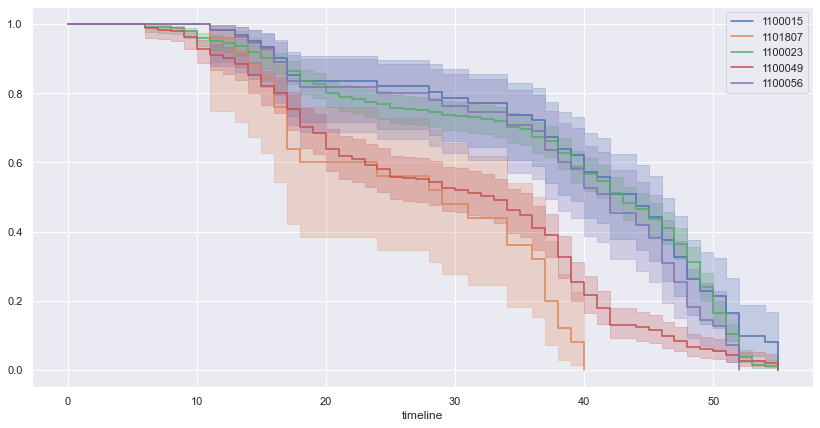

In [155]:
kmf2 = KaplanMeierFitter() 
df = events_ro
#list currently takes a max of 5 cities because of the ax elements in the plot at the end
cities_list = ['1100015','1101807','1100023','1100049','1100056'] 

T = df['week']     ## time to event
E = df['event']      ## event occurred or censored


#creating a the cohorts. this takes a list of index (named) keys
groups = df.loc[cities_list]
#create an empty series object to receive the dataframe for each city below
ix = pd.Series([])
for i in range(len(cities_list)):
    #create a temporary dataframe, holding the events for each city
    ix[i] = groups.loc[cities_list[i]].index
    #passing on the dataframe's time and event columns to the Kaplan-Meier function, and the index keys as labels (we can search the IBGE database for its name later)
    kmf2.fit(T[ix[i]], E[ix[i]], label=cities_list[i])    ## fit the cohort 1 data
    if i == 0:
        ax = kmf2.plot()
        figsize(14,7)
    elif i == 1:
        ax1 = kmf2.plot(ax=ax)
    elif i == 2:
        ax2 = kmf2.plot(ax=ax1)
    elif i == 3:
        ax3 = kmf2.plot(ax=ax2)
    #the following 'else' is not working for real... 'axnum' is not interpreted iteractively and I cannot use 'exec()' in the function call
    #this limits the list length to 5 elements (which is about as many lines we can see properly anyway...)
    else:
        axnum = "ax"+str(i)
        axprev = "ax"+str(i-1)
        axnum = kmf2.plot(ax=exec(axprev))


plt.show()

In [156]:
def plot_kmf(dataframe,cities):
    kmf2 = KaplanMeierFitter() 
    df = dataframe
    #list currently takes a max of 5 cities because of the ax elements in the plot at the end
    cities_list = cities

    T = df['week']     ## time to event
    E = df['event']      ## event occurred or censored


    #creating a the cohorts. this takes a list of index (named) keys
    groups = df.loc[cities_list]
    #create an empty series object to receive the dataframe for each city below
    ix = pd.Series([])
    for i in range(len(cities_list)):
        #create a temporary dataframe, holding the events for each city
        ix[i] = groups.loc[cities_list[i]].index
        #passing on the dataframe's time and event columns to the Kaplan-Meier function, and the index keys as labels (we can search the IBGE database for its name later)
        kmf2.fit(T[ix[i]], E[ix[i]], label=cities_list[i])    ## fit the cohort 1 data
        if i == 0:
            ax = kmf2.plot()
            figsize(14,7)
        elif i == 1:
            ax1 = kmf2.plot(ax=ax)
        elif i == 2:
            ax2 = kmf2.plot(ax=ax1)
        elif i == 3:
            ax3 = kmf2.plot(ax=ax2)
        #the following 'else' is not working for real... 'axnum' is not interpreted iteractively and I cannot use 'exec()' in the function call
        #this limits the list length to 5 elements (which is about as many lines we can see properly anyway...)
        else:
            axnum = "ax"+str(i)
            axprev = "ax"+str(i-1)
            axnum = kmf2.plot(ax=exec(axprev))


    plt.show()

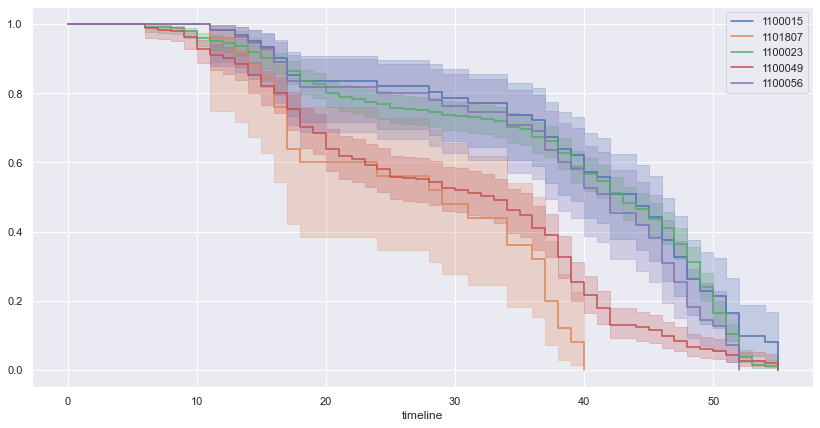

In [157]:
plot_kmf(events_ro,['1100015','1101807','1100023','1100049','1100056'])

---